In [217]:
import pandas as pd

In [218]:
import numpy as np

In [219]:
import matplotlib.pyplot as plt

In [220]:
import seaborn as sns

In [221]:
from sklearn.preprocessing import MinMaxScaler

In [222]:
%matplotlib inline

In [223]:
df = pd.read_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/raw/vgsales.csv")

In [224]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [225]:
df.dtypes # check data types

Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [226]:
df = df.drop(['Rank'], axis=1) # remove columns

In [227]:
df.head()

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [228]:
df = df.rename(columns={"Name": "Game Title", "Platform": "Console",
                        "Global_Sales": "Sales", "NA_Sales": "North American Sales",
                        "JP_Sales": "Japanese Sales", "EU_Sales": "EU Sales", 
                        "Other_Sales": "Other Sales", "Year": "Release Year",})  # rename columns

In [229]:
df.shape # check dimentions

(16598, 10)

In [230]:
df.count() # count rows

Game Title              16598
Console                 16598
Release Year            16327
Genre                   16598
Publisher               16540
North American Sales    16598
EU Sales                16598
Japanese Sales          16598
Other Sales             16598
Sales                   16598
dtype: int64

In [231]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)   #check duplicates 

number of duplicate rows:  (1, 10)


In [232]:
df = df.drop_duplicates() # drop duplicates

In [233]:
print(df.isnull().sum()) # missing values ( null )

Game Title                0
Console                   0
Release Year            270
Genre                     0
Publisher                58
North American Sales      0
EU Sales                  0
Japanese Sales            0
Other Sales               0
Sales                     0
dtype: int64


In [234]:
# 1. Fill categorical with "Unknown"
for col in ['Publisher']:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# 2. Release Year -> fill with median
if 'Release Year' in df.columns:
    df['Release Year'] = df['Release Year'].fillna(df['Release Year'].median())        

In [235]:
df.head()

,Game Title,Console,Release Year,Genre,Publisher,North American Sales,EU Sales,Japanese Sales,Other Sales,Sales
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [236]:
df.count() # count rows

Game Title              16597
Console                 16597
Release Year            16597
Genre                   16597
Publisher               16597
North American Sales    16597
EU Sales                16597
Japanese Sales          16597
Other Sales             16597
Sales                   16597
dtype: int64

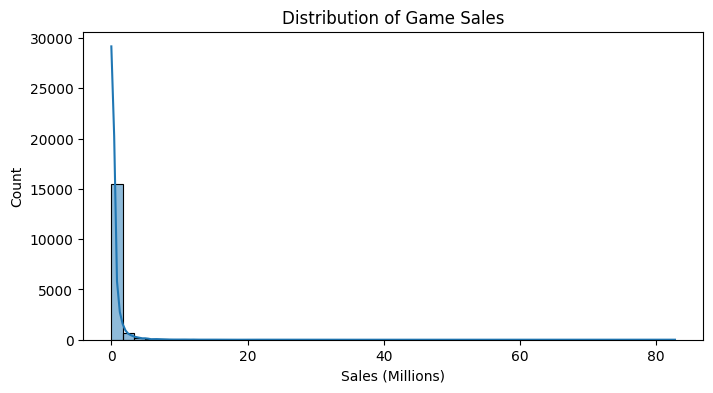

In [237]:
# Histogram for Game Sales Distribution 

plt.figure(figsize=(8,4))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title("Distribution of Game Sales")
plt.xlabel("Sales (Millions)")
plt.ylabel("Count")
plt.show()

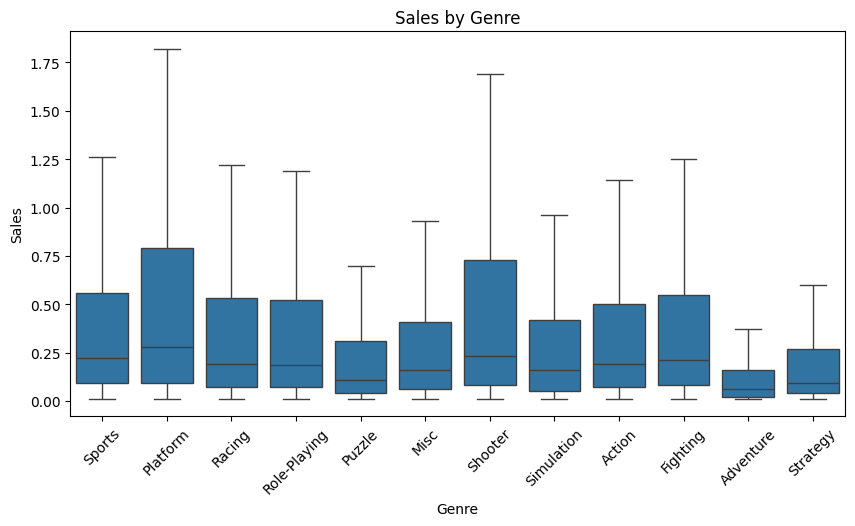

In [238]:
# Boxplot for Sales by Genre

plt.figure(figsize=(10,5))
sns.boxplot(x='Genre', y='Sales', data=df, showfliers=False)
plt.xticks(rotation=45)
plt.title("Sales by Genre")
plt.show()

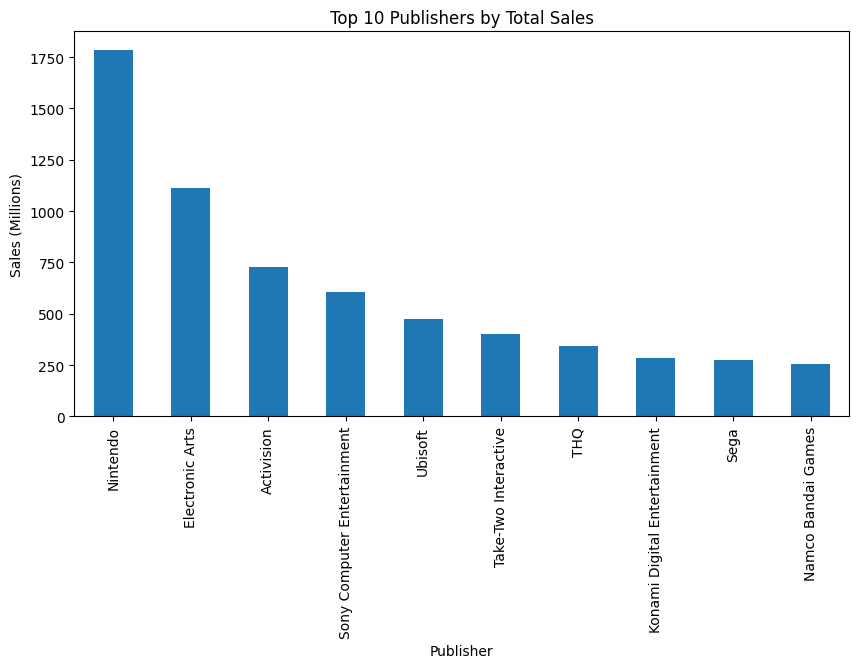

In [239]:
#Barplot for top 10 Publishers by Sales
top_publishers = df.groupby('Publisher')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_publishers.plot(kind='bar')
plt.title("Top 10 Publishers by Total Sales")
plt.ylabel("Sales (Millions)")
plt.show()

In [240]:
# Top publisher = Good Sales
top_publishers = ['Nintendo', 'Electronic Arts', 'Activision', 'Sony Computer Entertainment', 'Ubisoft', 'Take-Two Interactive']

df['Big Publisher'] = df['Publisher'].apply(lambda x: 1 if x in top_publishers else 0)

In [241]:
# One-hot encode Genre & Platform
df = pd.get_dummies(df, columns=['Genre','Console'], drop_first=True)

# For Publisher/Developer, keep top 30 and label others as "Other"
def cap_top(series, n=30):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), "Other")

df['Publisher'] = cap_top(df['Publisher'])

# One-hot encode after capping
df = pd.get_dummies(df, columns=['Publisher'], drop_first=True)

In [242]:
df.head()

,Game Title,Release Year,North American Sales,EU Sales,Japanese Sales,Other Sales,Sales,Big Publisher,Genre_Adventure,Genre_Fighting,...,Publisher_Sony Computer Entertainment,Publisher_Square Enix,Publisher_THQ,Publisher_Take-Two Interactive,Publisher_Tecmo Koei,Publisher_Ubisoft,Publisher_Unknown,Publisher_Vivendi Games,Publisher_Warner Bros. Interactive Entertainment,Publisher_Zoo Digital Publishing
0,Wii Sports,2006.0,41.49,29.02,3.77,8.46,82.74,1,False,False,...,False,False,False,False,False,False,False,False,False,False
1,Super Mario Bros.,1985.0,29.08,3.58,6.81,0.77,40.24,1,False,False,...,False,False,False,False,False,False,False,False,False,False
2,Mario Kart Wii,2008.0,15.85,12.88,3.79,3.31,35.82,1,False,False,...,False,False,False,False,False,False,False,False,False,False
3,Wii Sports Resort,2009.0,15.75,11.01,3.28,2.96,33.00,1,False,False,...,False,False,False,False,False,False,False,False,False,False
4,Pokemon Red/Pokemon Blue,1996.0,11.27,8.89,10.22,1.00,31.37,1,False,False,...,False,False,False,False,False,False,False,False,False,False


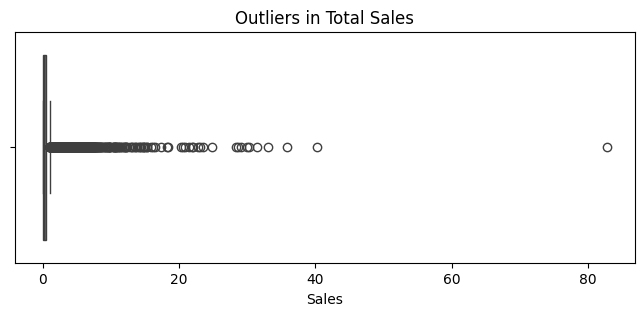

In [243]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['Sales'])
plt.title("Outliers in Total Sales")
plt.show()

In [244]:
print(df.isnull().sum()) # missing values ( null )

Game Title                                          0
Release Year                                        0
North American Sales                                0
EU Sales                                            0
Japanese Sales                                      0
                                                   ..
Publisher_Ubisoft                                   0
Publisher_Unknown                                   0
Publisher_Vivendi Games                             0
Publisher_Warner Bros. Interactive Entertainment    0
Publisher_Zoo Digital Publishing                    0
Length: 79, dtype: int64


In [245]:
# Scale Sales & Regional Sales between 0-1 
# Define the sales columns 
sales_cols = ['Sales', 'North American Sales', 'EU Sales', 'Japanese Sales', 'Other Sales']

scaler = MinMaxScaler()

# Fit + transform the sales columns
df[sales_cols] = scaler.fit_transform(df[sales_cols])

In [247]:
# Create decade column
df['Decade'] = (df['Release Year'] // 10) * 10

# Percentages of sales per region 
df['NA Share'] = df['North American Sales'] / df['Sales']
df['EU Share'] = df['EU Sales'] / df['Sales']
df['JP Share'] = df['Japanese Sales'] / df['Sales']
df['Other Share'] = df['Other Sales'] / df['Sales']

# New Game ?
df['Is Recent'] = df['Release Year'].apply(lambda x: 1 if x >= 2010 else 0)

In [248]:
df.head()

,Game Title,Release Year,North American Sales,EU Sales,Japanese Sales,Other Sales,Sales,Big Publisher,Genre_Adventure,Genre_Fighting,...,Publisher_Unknown,Publisher_Vivendi Games,Publisher_Warner Bros. Interactive Entertainment,Publisher_Zoo Digital Publishing,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent
0,Wii Sports,2006.0,1.000000,1.000000,0.368885,0.800378,1.000000,1,False,False,...,False,False,False,False,2000.0,1.000000,1.000000,0.368885,0.800378,0
1,Super Mario Bros.,1985.0,0.700892,0.123363,0.666341,0.072848,0.486281,1,False,False,...,False,False,False,False,1980.0,1.441332,0.253687,1.370280,0.149806,0
2,Mario Kart Wii,2008.0,0.382020,0.443832,0.370841,0.313150,0.432854,1,False,False,...,False,False,False,False,2000.0,0.882561,1.025362,0.856736,0.723455,0
3,Wii Sports Resort,2009.0,0.379610,0.379394,0.320939,0.280038,0.398767,1,False,False,...,False,False,False,False,2000.0,0.951958,0.951416,0.804829,0.702259,0
4,Pokemon Red/Pokemon Blue,1996.0,0.271632,0.306340,1.000000,0.094607,0.379064,1,False,False,...,False,False,False,False,1990.0,0.716585,0.808149,2.638074,0.249581,0


In [249]:
df.to_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/cleaned/VGSales.csv", index=False)